# HyperAck final benchmark

**Goal:** rank every finished experiment on the same held-out test set — visually.

## Why this notebook?
Fifteen strategies only matter if we compare them fairly. This notebook loads all `results/*.json` files, ranks them, and draws a visual leaderboard.

## Approach
1. Load experiment JSON records written by notebooks 01–15.
2. Drop incomplete/skipped runs (e.g. TabPFN without license).
3. Rank by ROC-AUC → F1 → accuracy.
4. Report **recall** alongside F1 (share of true `hyper_ack=1` caught).
5. Plot ROC-AUC, recall, recall-vs-F1, and lift vs baseline.
6. Export `benchmark_summary.csv` / `.json` / `benchmark_dashboard.json`.

## What changed?
No new model training — only aggregation, charts, and ranking. Metrics include ROC-AUC, average precision, F1, **recall**, and accuracy.


### Setup
Locate the experiment folder and load helpers.


In [9]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "shared" / "protocol.py").exists():
        EXPERIMENT_ROOT = candidate
        break
    if (candidate / "hyperack_exp" / "shared" / "protocol.py").exists():
        EXPERIMENT_ROOT = candidate / "hyperack_exp"
        break
else:
    raise RuntimeError("Run this notebook from the HyperAck project directory.")
os.chdir(EXPERIMENT_ROOT)
import sys
sys.path.insert(0, str(EXPERIMENT_ROOT))
from shared.protocol import RESULTS_DIR


### Build leaderboard
Load JSON results, skip incomplete runs, and rank experiments.


In [10]:
records = []
skipped = []
for path in sorted(RESULTS_DIR.glob("[0-9][0-9]_*.json")):
    rec = json.loads(path.read_text())
    metrics = rec.get("metrics", {})
    if metrics.get("roc_auc") is None:
        skipped.append(rec)
        continue
    records.append({
        "exp_id": rec["exp_id"],
        "name": rec["name"],
        "experiment": f"{rec['exp_id']} - {rec['name']}",
        "strategy": rec["strategy"],
        "model": rec["best_model"],
        "features": rec["feature_count"],
        **{k: metrics[k] for k in ["roc_auc", "avg_precision", "f1", "recall", "accuracy", "fit_seconds", "predict_seconds", "threshold"]},
        "notes": rec.get("notes", ""),
    })

leaderboard = pd.DataFrame(records).sort_values(
    ["roc_auc", "f1", "accuracy"], ascending=False
).reset_index(drop=True)
leaderboard.index += 1
leaderboard["rank"] = leaderboard.index
baseline_roc = float(leaderboard.loc[leaderboard["exp_id"] == "01", "roc_auc"].iloc[0])
safe_roc = float(leaderboard.loc[leaderboard["exp_id"] == "14", "roc_auc"].iloc[0])
leaderboard["delta_vs_baseline"] = leaderboard["roc_auc"] - baseline_roc
leaderboard["gap_vs_safe"] = leaderboard["roc_auc"] - safe_roc
display_cols = [
    "rank", "experiment", "model", "features", "roc_auc", "avg_precision",
    "f1", "recall", "accuracy", "fit_seconds", "delta_vs_baseline", "gap_vs_safe",
]
leaderboard[display_cols]


,rank,experiment,model,features,roc_auc,avg_precision,f1,recall,accuracy,fit_seconds,delta_vs_baseline,gap_vs_safe
1,1,09 - lightgbm_tuned,RandomizedSearchCV(LGBMClassifier),34,0.979256,0.977322,0.928361,0.911368,0.934293,194.903,0.006213,0.040601
2,2,08 - xgboost_tuned,RandomizedSearchCV(XGBClassifier),34,0.978809,0.977714,0.927835,0.910405,0.933843,19.771,0.005766,0.040153
3,3,15 - full_fe_best_blend,"ProbabilityBlend(LGBMClassifier, XGBClassifier)",34,0.978098,0.977457,0.928817,0.911368,0.934743,9.017,0.005055,0.039443
4,4,12 - threshold_calibration,CalibratedClassifierCV(LGBMClassifier),34,0.977950,0.977614,0.920523,0.881503,0.928893,13.266,0.004907,0.039295
5,5,06 - interactions_bins,LGBMClassifier,38,0.977783,0.977185,0.928150,0.908478,0.934293,4.385,0.004740,0.039127
6,6,10 - histgb_sklearn,HistGradientBoostingClassifier,34,0.977556,0.977170,0.931628,0.912331,0.937444,4.083,0.004513,0.038900
7,7,03 - fare_pricing_features,LGBMClassifier,21,0.976697,0.975898,0.918839,0.899807,0.925743,2.866,0.003654,0.038042
8,8,04 - time_cyclical_features,LGBMClassifier,20,0.974036,0.972832,0.920494,0.897881,0.927543,3.194,0.000993,0.035381
9,9,13 - stacking_ensemble,StackingClassifier,34,0.973726,0.971515,0.929936,0.914258,0.935644,19.909,0.000683,0.035070
10,10,01 - baseline_current,xgboost,13,0.973043,0.972153,0.911504,0.893064,0.918992,0.687,0.000000,0.034388


### Visual leaderboard
ROC-AUC ranking, **recall**, recall vs F1, and lift vs baseline.


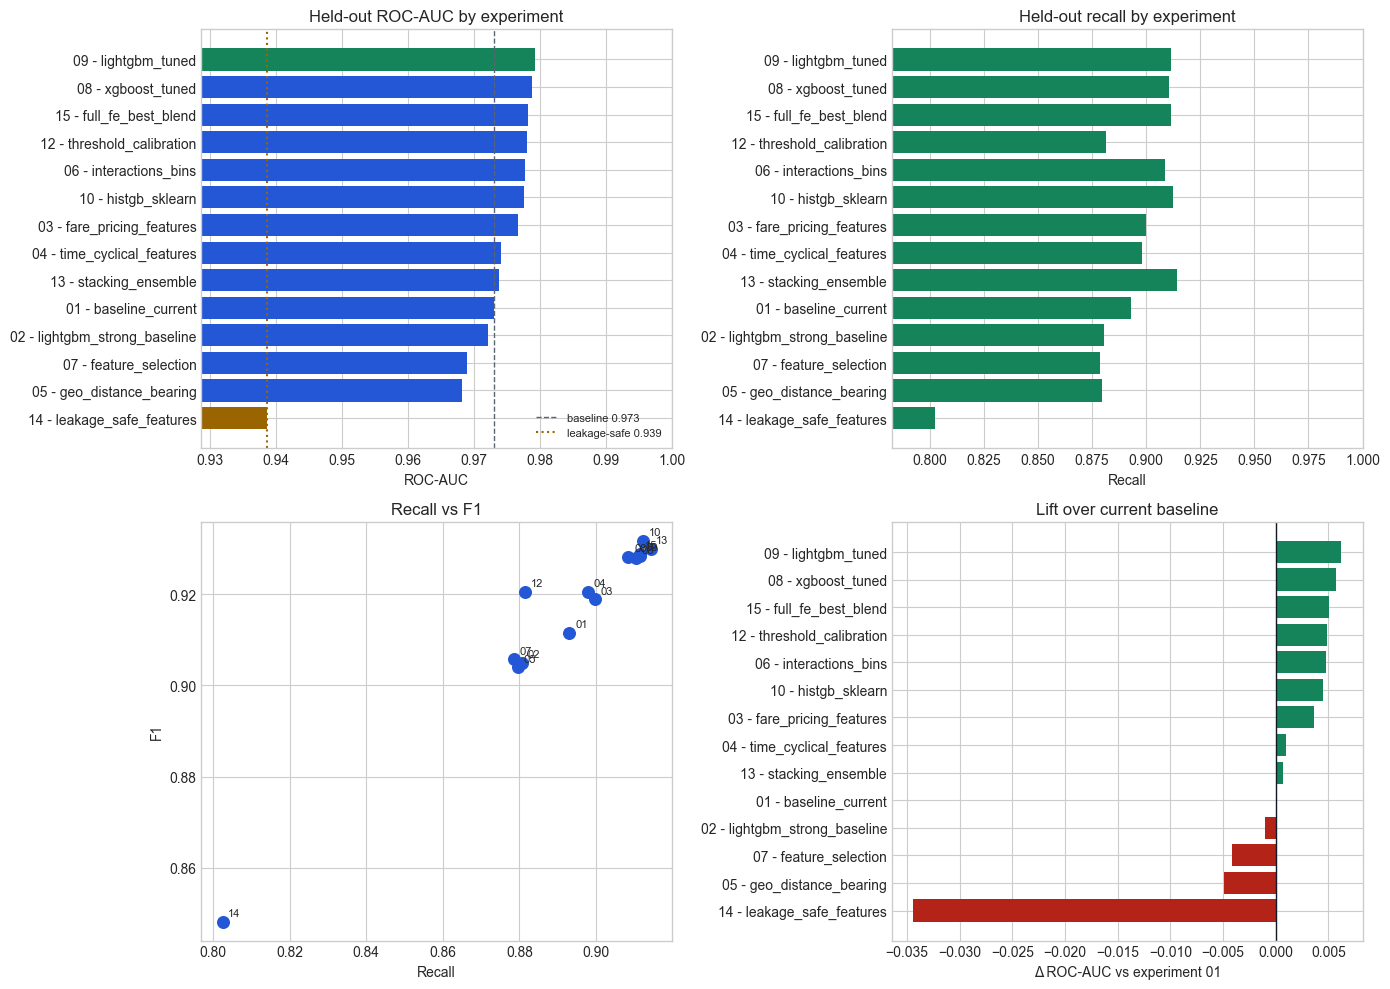

In [11]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) ROC-AUC ranking
plot_df = leaderboard.sort_values("roc_auc")
colors = ["#16845B" if e == leaderboard.iloc[0]["experiment"] else
          "#9A6500" if e.startswith("14 -") else "#2457D6"
          for e in plot_df["experiment"]]
axes[0, 0].barh(plot_df["experiment"], plot_df["roc_auc"], color=colors)
axes[0, 0].axvline(baseline_roc, color="#5B6472", ls="--", lw=1, label=f"baseline {baseline_roc:.3f}")
axes[0, 0].axvline(safe_roc, color="#9A6500", ls=":", lw=1.5, label=f"leakage-safe {safe_roc:.3f}")
axes[0, 0].set_xlim(max(0.90, plot_df["roc_auc"].min() - 0.01), 1.0)
axes[0, 0].set_xlabel("ROC-AUC")
axes[0, 0].set_title("Held-out ROC-AUC by experiment")
axes[0, 0].legend(loc="lower right", fontsize=8)

# 2) Recall ranking
axes[0, 1].barh(plot_df["experiment"], plot_df["recall"], color="#16845B")
axes[0, 1].set_xlim(max(0.75, plot_df["recall"].min() - 0.02), 1.0)
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_title("Held-out recall by experiment")

# 3) Recall vs F1
axes[1, 0].scatter(leaderboard["recall"], leaderboard["f1"], s=70, c="#2457D6")
for _, row in leaderboard.iterrows():
    axes[1, 0].annotate(row["exp_id"], (row["recall"], row["f1"]),
                        textcoords="offset points", xytext=(4, 4), fontsize=8)
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("F1")
axes[1, 0].set_title("Recall vs F1")

# 4) Lift vs baseline
lift = leaderboard.sort_values("delta_vs_baseline")
bar_colors = ["#16845B" if v >= 0 else "#B42318" for v in lift["delta_vs_baseline"]]
axes[1, 1].barh(lift["experiment"], lift["delta_vs_baseline"], color=bar_colors)
axes[1, 1].axvline(0, color="#111827", lw=1)
axes[1, 1].set_xlabel("Δ ROC-AUC vs experiment 01")
axes[1, 1].set_title("Lift over current baseline")

plt.tight_layout()
plt.show()


### Winner summary and exports


In [12]:
winner = leaderboard.iloc[0]
safe = leaderboard.loc[leaderboard["exp_id"] == "14"].iloc[0]

summary = {
    "winner": winner["experiment"],
    "winner_roc_auc": float(winner["roc_auc"]),
    "winner_f1": float(winner["f1"]),
    "winner_recall": float(winner["recall"]),
    "leakage_safe": safe["experiment"],
    "leakage_safe_roc_auc": float(safe["roc_auc"]),
    "leakage_safe_recall": float(safe["recall"]),
    "gap_winner_minus_safe": float(winner["roc_auc"] - safe["roc_auc"]),
    "completed_experiments": int(len(leaderboard)),
    "skipped_experiments": [
        {"exp_id": s["exp_id"], "name": s["name"], "notes": s.get("notes", "")}
        for s in skipped
    ],
}

benchmark_csv = RESULTS_DIR / "benchmark_summary.csv"
benchmark_json = RESULTS_DIR / "benchmark_summary.json"
dashboard_json = RESULTS_DIR / "benchmark_dashboard.json"
leaderboard.to_csv(benchmark_csv, index=False)
leaderboard.to_json(benchmark_json, orient="records", indent=2)
dashboard_json.write_text(json.dumps({
    **summary,
    "baseline_roc": baseline_roc,
    "rows": leaderboard.to_dict(orient="records"),
}, indent=2) + "\n")

print("Winner:", summary["winner"], f"ROC-AUC={summary['winner_roc_auc']:.4f} recall={summary['winner_recall']:.4f}")
print("Leakage-safe:", summary["leakage_safe"], f"ROC-AUC={summary['leakage_safe_roc_auc']:.4f}")
print("Gap (winner - safe):", f"{summary['gap_winner_minus_safe']:.4f}")
if skipped:
    print("Skipped:", ", ".join(f"{s['exp_id']}-{s['name']}" for s in skipped))
summary


Winner: 09 - lightgbm_tuned ROC-AUC=0.9793 recall=0.9114
Leakage-safe: 14 - leakage_safe_features ROC-AUC=0.9387
Gap (winner - safe): 0.0406
Skipped: 11-tabpfn


{'winner': '09 - lightgbm_tuned',
 'winner_roc_auc': 0.9792561709107952,
 'winner_f1': 0.9283611383709519,
 'winner_recall': 0.9113680154142582,
 'leakage_safe': '14 - leakage_safe_features',
 'leakage_safe_roc_auc': 0.9386554184242045,
 'leakage_safe_recall': 0.802504816955684,
 'gap_winner_minus_safe': 0.040600752486590674,
 'completed_experiments': 14,
 'skipped_experiments': [{'exp_id': '11',
   'name': 'tabpfn',
   'notes': 'Skipped: TabPFN license/token required (set TABPFN_TOKEN).'}]}

## How to read the result

1. **Winner** = highest ROC-AUC on the shared test set (green bar).
2. **Recall** = of all true hyper_ack=1 cases, how many we catch. Best recall here is often stacking (13), even if ROC-AUC winner is 09.
3. **Experiment 14** = honest pre-decision score without final fares (amber reference).
4. If winner ≫ 14, much of the lift may come from post-decision fare features — do not deploy that blindly.
5. Prefer experiment 14 (or a leakage-safe retrain of the winner) for production.
